# **Vehicle Identification Baseline**

**Goals:**
- Detect vehicles from images/video
- Identify coarse vehicle class (car, truck, bus, motorcycle)
- Save crops for downstream plate detection / OCR
- Measure inference latency

In [1]:
# Import required packages
import os
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [2]:
# Add project root to sys.path for local imports
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [4]:
# Import local modules
from src.configs.settings import settings

In [5]:
# Load vehicle detection model
model = YOLO(settings.models.vehicle_detector)

In [6]:
# Define utility functions

# convert BGR (OpenCV default) to RGB for visualization
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load image using OpenCV and handle potential errors
def load_image(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return image

# Run vehicle detection on the image and return detections along with latency
def detect_vehicles(image, model, conf_threshold=0.4):
    start = time.perf_counter()
    results = model.predict(image, conf=conf_threshold, verbose=False)
    latency_ms = (time.perf_counter() - start) * 1000

    detections = []
    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0].item())
            cls_name = model.names[cls_id]
            
            if cls_name not in settings.models.vehicle_target_classes:
                continue
            
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0].item())

            detections.append({
                "class_id": cls_id,
                "class_name": cls_name,
                "confidence": conf,
                "bbox": (x1, y1, x2, y2)
            })

    return detections, latency_ms

# Draw bounding boxes and labels on the image for visualization
def draw_detections(image, detections):
    canvas = image.copy()
    for det in detections:
        x1, y1, x2, y2 = det["bbox"]
        cls_name = det["class_name"]
        conf = det["confidence"]
        label = f"{cls_name}: {conf:.2f}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            canvas,
            label,
            (x1, max(25, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )
    return canvas

# Crop the image to the bounding box, ensuring we stay within image boundaries
def crop_bbox(image, bbox):
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w - 1))
    y2 = max(0, min(y2, h - 1))
    return image[y1:y2, x1:x2].copy()

In [7]:
# Define paths
VEHICLE_IMAGES_DIR = settings.VEHICLE_INPUT_DIR / "images"
vehicle_images = list(VEHICLE_IMAGES_DIR.glob("*.jpg")) + list(VEHICLE_IMAGES_DIR.glob("*.png")) + list(VEHICLE_IMAGES_DIR.glob("*.jpeg"))
print(f"Found {len(vehicle_images)} vehicle images")

vehicle_images[:5]

Found 1 vehicle images


[WindowsPath('C:/Users/Samuel.Ozechi/Downloads/projects/vision-based-access-intelligence/data/vehicle_identification/inputs/images/image_1.jpg')]

In [8]:
# Run detection on the first sample image and print results
image_path = vehicle_images[0]
image = load_image(image_path)

detections, latency_ms = detect_vehicles(image, model, settings.thresholds.vehicle_conf)

print("Image:", image_path.name)
print("Latency (ms):", round(latency_ms, 2))
print("Detections:", detections)

Image: image_1.jpg
Latency (ms): 183.29
Detections: [{'class_id': 2, 'class_name': 'car', 'confidence': 0.947637677192688, 'bbox': (773, 473, 1072, 569)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9452856183052063, 'bbox': (415, 478, 734, 569)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9421535134315491, 'bbox': (419, 258, 731, 377)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.939365804195404, 'bbox': (67, 478, 373, 569)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9273509383201599, 'bbox': (71, 249, 370, 380)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9252848029136658, 'bbox': (416, 51, 729, 163)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9199561476707458, 'bbox': (64, 45, 373, 162)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.918816864490509, 'bbox': (777, 259, 1070, 380)}, {'class_id': 2, 'class_name': 'car', 'confidence': 0.9113665819168091, 'bbox': (778, 47, 1068, 164)}]


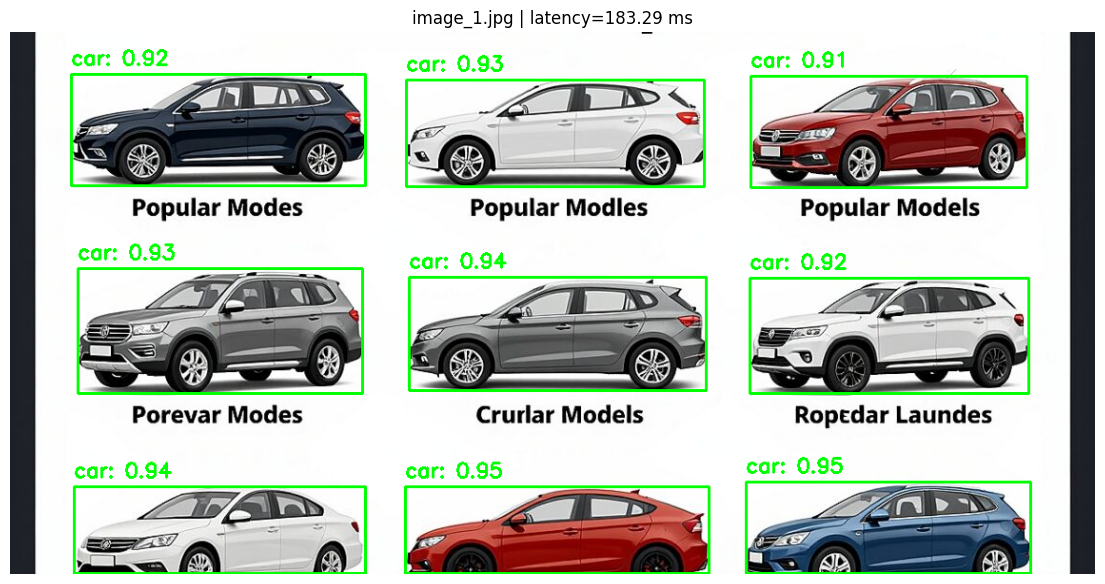

In [9]:
# Annotate and visualize results
annotated = draw_detections(image, detections)

plt.figure(figsize=(14, 8))
plt.imshow(bgr_to_rgb(annotated))
plt.title(f"{image_path.name} | latency={latency_ms:.2f} ms")
plt.axis("off")
plt.show()

In [10]:
# Save cropped vehicle images
VEHICLE_OUTPUT_IMAGE_DIR = settings.VEHICLE_OUTPUT_DIR / "images"
saved = []

for idx, det in enumerate(detections):
    crop = crop_bbox(image, det["bbox"])
    crop_name = f"{image_path.stem}_veh_{idx}_{det['class_name']}.jpg"
    crop_path = VEHICLE_OUTPUT_IMAGE_DIR / crop_name
    cv2.imwrite(str(crop_path), crop)
    saved.append(crop_path.name)

saved

['image_1_veh_0_car.jpg',
 'image_1_veh_1_car.jpg',
 'image_1_veh_2_car.jpg',
 'image_1_veh_3_car.jpg',
 'image_1_veh_4_car.jpg',
 'image_1_veh_5_car.jpg',
 'image_1_veh_6_car.jpg',
 'image_1_veh_7_car.jpg',
 'image_1_veh_8_car.jpg']

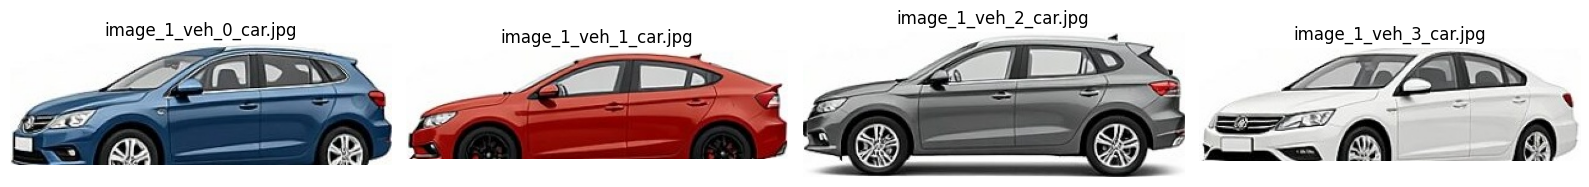

In [11]:
# Show cropped vehicle images
crop_files = list(VEHICLE_OUTPUT_IMAGE_DIR.glob(f"{image_path.stem}_veh_*"))

fig, axes = plt.subplots(1, min(len(crop_files), 4), figsize=(16, 5))
if len(crop_files) == 1:
    axes = [axes]

for ax, crop_file in zip(axes, crop_files[:4]):
    crop_img = load_image(crop_file)
    ax.imshow(bgr_to_rgb(crop_img))
    ax.set_title(crop_file.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# # Run detection on all sample images and compile results into a DataFrame
# records = []

# for img_path in sample_images:
#     image = load_image(img_path)
#     detections, latency_ms = detect_vehicles(image, model, settings.thresholds.vehicle_conf)

#     records.append({
#         "image_name": img_path.name,
#         "num_detections": len(detections),
#         "latency_ms": round(latency_ms, 2),
#         "classes_detected": ", ".join([d["class_name"] for d in detections]) if detections else ""
#     })

# results_df = pd.DataFrame(records)
# results_df.head()

In [19]:
# # Print summary statistics
# print("Average latency (ms):", round(results_df["latency_ms"].mean(), 2))
# print("Max latency (ms):", round(results_df["latency_ms"].max(), 2))
# print("Min latency (ms):", round(results_df["latency_ms"].min(), 2))

In [20]:
# # inspect failures and empty detections
# failed_df = results_df[results_df["num_detections"] == 0]
# failed_df

In [21]:
# # Save results to CSV
# csv_path = settings.OUTPUT_DIR / "vehicle_detection_baseline_results.csv"
# results_df.to_csv(csv_path, index=False)
# print("Saved:", csv_path)

In [12]:
# Video demonstration of the prototype

VIDEO_PATH = settings.VEHICLE_INPUT_DIR / "videos" / "sample_video.mp4"
VIDEO_OUTPUT = settings.VEHICLE_OUTPUT_DIR / "videos" / "vehicle_detection_demo.mp4"

In [13]:
# Video inference script
cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(VIDEO_OUTPUT), fourcc, fps, (width, height))

frame_count = 0
latencies = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    detections, latency_ms = detect_vehicles(frame, model, settings.thresholds.vehicle_conf)
    annotated = draw_detections(frame, detections)

    writer.write(annotated)
    latencies.append(latency_ms)
    frame_count += 1

cap.release()
writer.release()

print("Processed frames:", frame_count)
print("Avg latency (ms):", round(np.mean(latencies), 2) if latencies else None)
print("Saved video:", VIDEO_OUTPUT)

Processed frames: 2600
Avg latency (ms): 48.99
Saved video: C:\Users\Samuel.Ozechi\Downloads\projects\vision-based-access-intelligence\data\vehicle_identification\outputs\videos\vehicle_detection_demo.mp4
